In [22]:
# Import bibliotek
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)

In [23]:
# Wczytanie danych
pred_df = pd.read_csv("Output_files/predictions.csv")

pred_df.head()

,fold,test_dT,model,pressure_true,pressure_pred,dT_true,dT_pred
0,2,16.2,AN-BL,0.0,-0.346457,16.2,15.871121
1,2,16.2,AN-BL,0.0,-0.327170,16.2,15.831001
2,2,16.2,AN-BL,0.0,-0.329210,16.2,15.827022
3,2,16.2,AN-BL,10.0,9.746948,16.2,15.896256
4,2,16.2,AN-BL,10.0,9.744743,16.2,15.922097


In [24]:
# Podstawowe informacje o danych
print(pred_df.shape)
print(pred_df.columns)

pred_df.describe()

(5365, 7)
Index(['fold', 'test_dT', 'model', 'pressure_true', 'pressure_pred', 'dT_true',
       'dT_pred'],
      dtype='str')


,fold,test_dT,pressure_true,pressure_pred,dT_true,dT_pred
count,5365.000000,5365.000000,5365.000000,5365.000000,5365.000000,5365.000000
mean,5.653308,31.491705,4.134203,4.120215,31.491705,31.391016
std,2.218287,9.458419,3.405493,3.080748,9.458419,9.322014
min,2.000000,16.200000,0.000000,-0.346457,16.200000,5.056667
25%,4.000000,24.700000,0.500000,0.982597,24.700000,24.643728
50%,6.000000,33.000000,4.000000,3.968405,33.000000,32.584667
75%,8.000000,41.800000,7.000000,6.455278,41.800000,41.785667
max,9.000000,45.700000,10.000000,10.143876,45.700000,45.935305


In [26]:
# Dodanie residuals
pred_df["pressure_error"] = (
    pred_df["pressure_true"] - pred_df["pressure_pred"]
)

pred_df["dT_error"] = (
    pred_df["dT_true"] - pred_df["dT_pred"]
)

pred_df["pressure_abs_error"] = np.abs(pred_df["pressure_error"])

pred_df["dT_abs_error"] = np.abs(pred_df["dT_error"])

# 1. MAE per temperatura

In [27]:
rows = []

for model in pred_df["model"].unique():

    for dT in sorted(pred_df["test_dT"].unique()):

        df_sub = pred_df[
            (pred_df["model"] == model) &
            (pred_df["test_dT"] == dT)
        ]

        rows.append({
            "model": model,
            "dT": dT,

            "pressure_mae": mean_absolute_error(
                df_sub["pressure_true"],
                df_sub["pressure_pred"]
            ),

            "dT_mae": mean_absolute_error(
                df_sub["dT_true"],
                df_sub["dT_pred"]
            )
        })

mae_temp_df = pd.DataFrame(rows)
mae_temp_df.head()

,model,dT,pressure_mae,dT_mae
0,AN-BL,16.2,0.238672,0.346233
1,AN-BL,20.5,0.099962,0.091679
2,AN-BL,24.7,0.095791,0.064818
3,AN-BL,27.4,0.079743,0.077598
4,AN-BL,33.0,0.085034,0.052879


# 2. Wykres MAE ciśnienia per temperatura

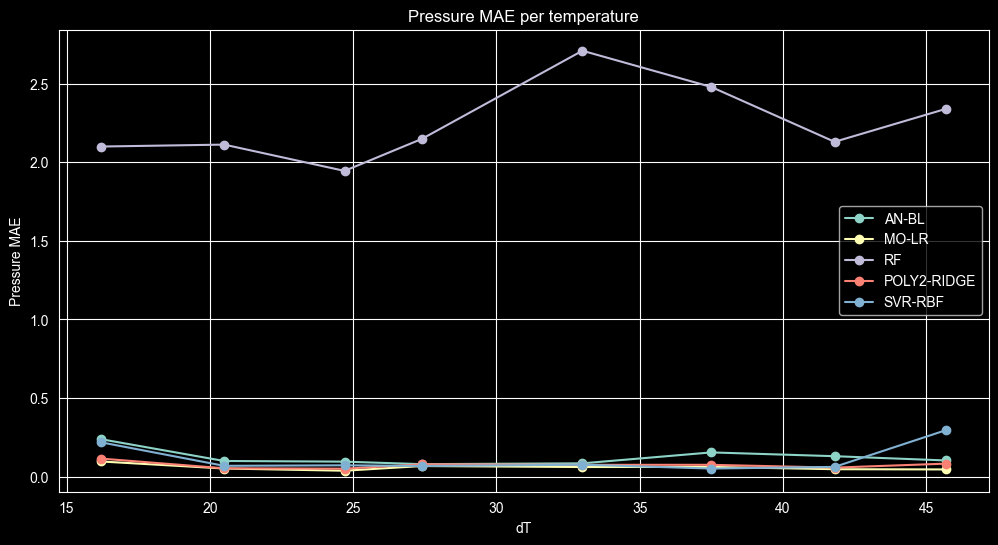

In [28]:
plt.figure(figsize=(12, 6))

for model in mae_temp_df["model"].unique():

    df_m = mae_temp_df[
        mae_temp_df["model"] == model
    ]

    plt.plot(
        df_m["dT"],
        df_m["pressure_mae"],
        marker="o",
        label=model
    )

plt.xlabel("dT")
plt.ylabel("Pressure MAE")
plt.title("Pressure MAE per temperature")
plt.legend()
plt.grid(True)

plt.show()

# 3. Wykres MAE temperatury per temperatura

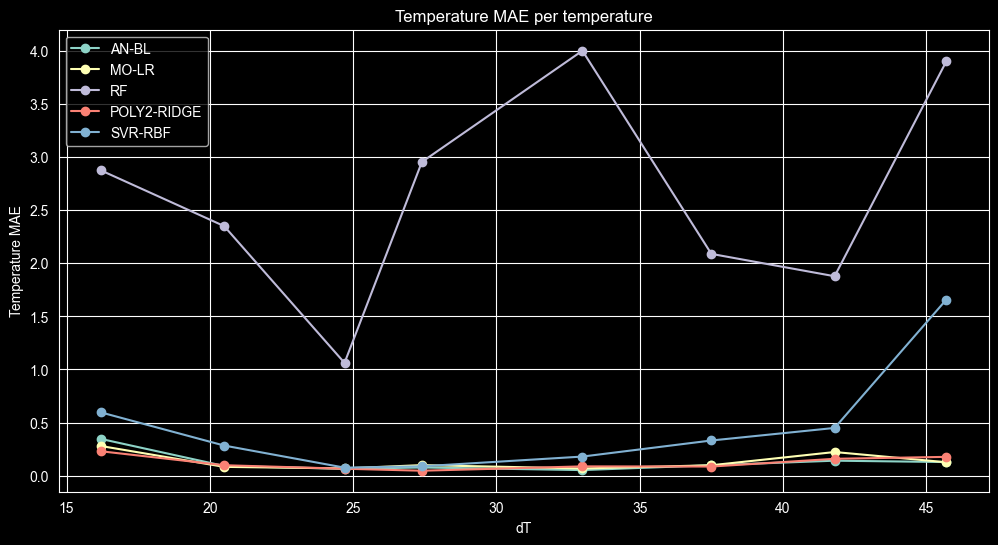

In [29]:
plt.figure(figsize=(12, 6))

for model in mae_temp_df["model"].unique():

    df_m = mae_temp_df[
        mae_temp_df["model"] == model
    ]

    plt.plot(
        df_m["dT"],
        df_m["dT_mae"],
        marker="o",
        label=model
    )

plt.xlabel("dT")
plt.ylabel("Temperature MAE")
plt.title("Temperature MAE per temperature")
plt.legend()
plt.grid(True)

plt.show()

# 4. Histogram residuals

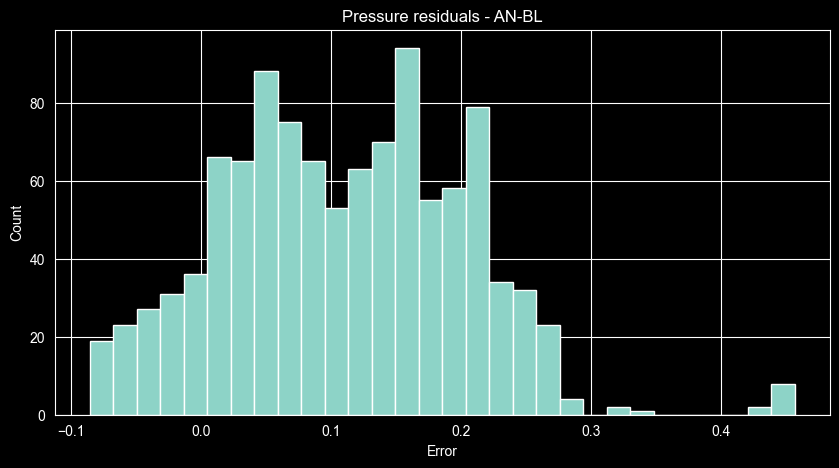

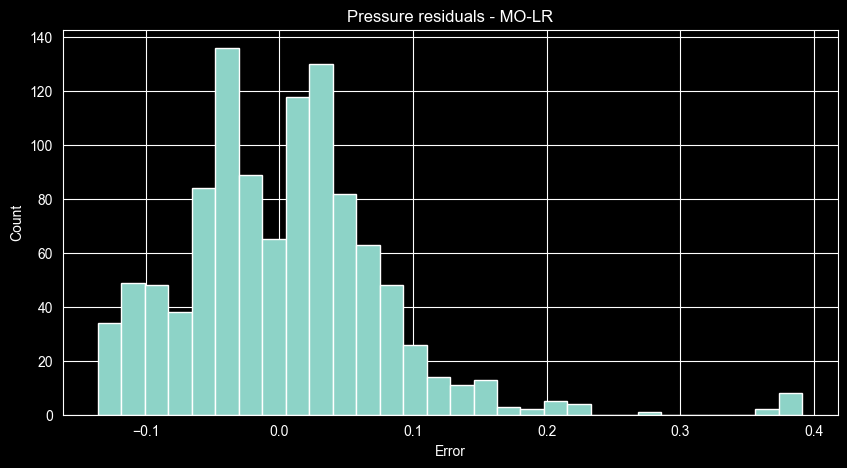

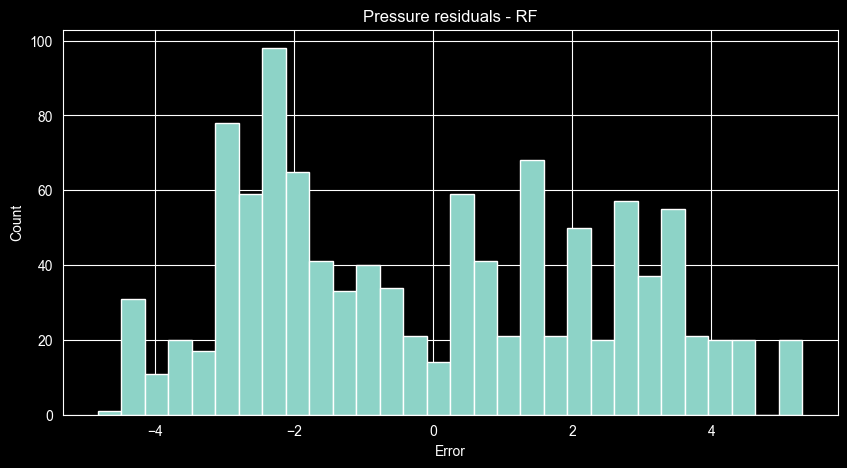

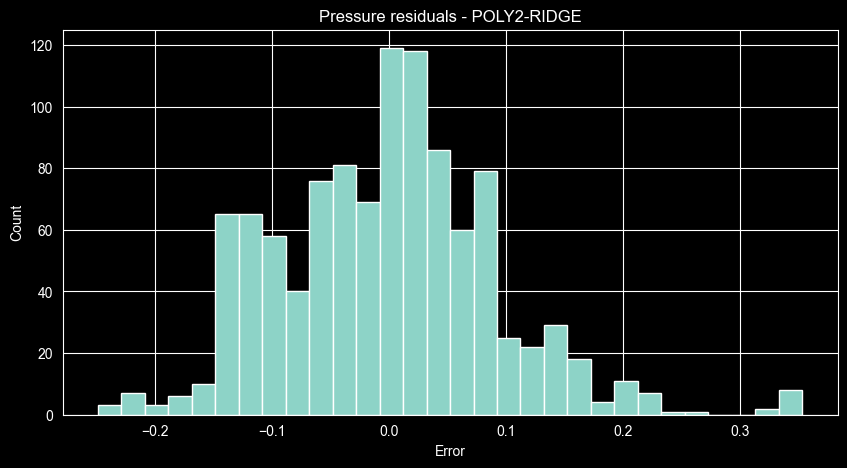

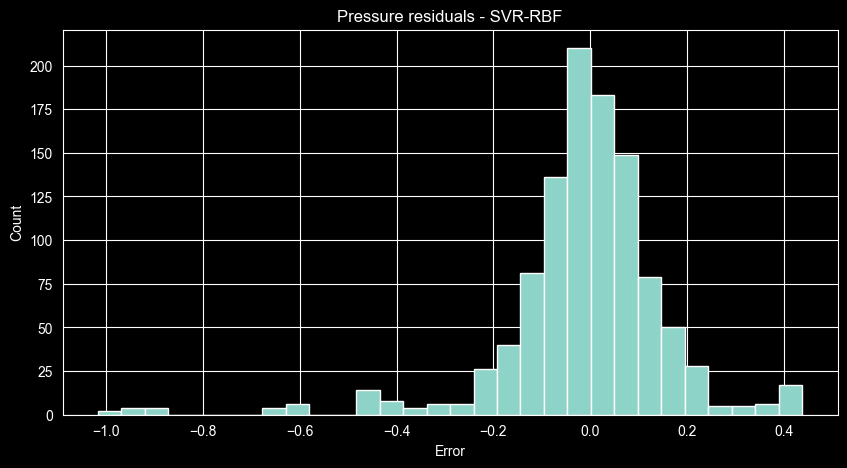

In [30]:
for model in pred_df["model"].unique():

    df_m = pred_df[
        pred_df["model"] == model
    ]

    plt.figure(figsize=(10, 5))

    plt.hist(
        df_m["pressure_error"],
        bins=30
    )

    plt.title(f"Pressure residuals - {model}")
    plt.xlabel("Error")
    plt.ylabel("Count")

    plt.show()

# 5. Predicted vs True — pressure

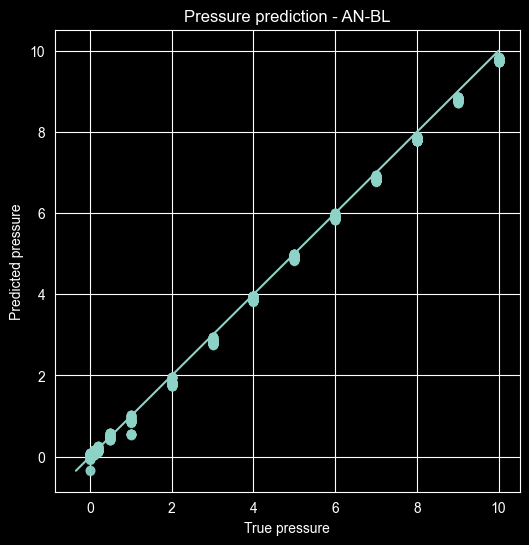

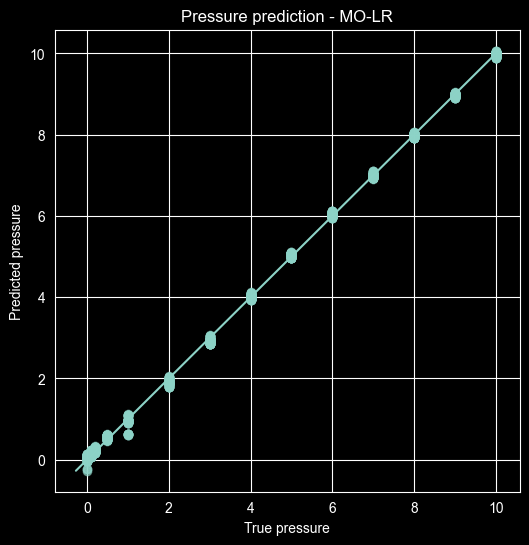

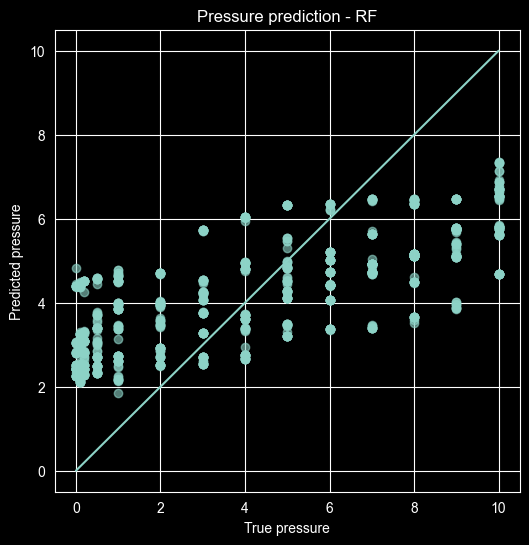

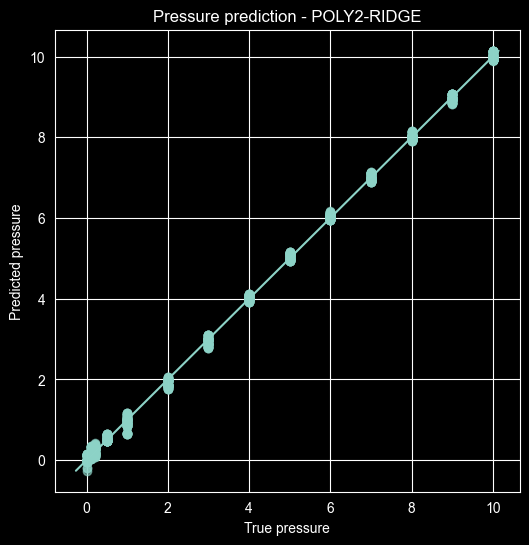

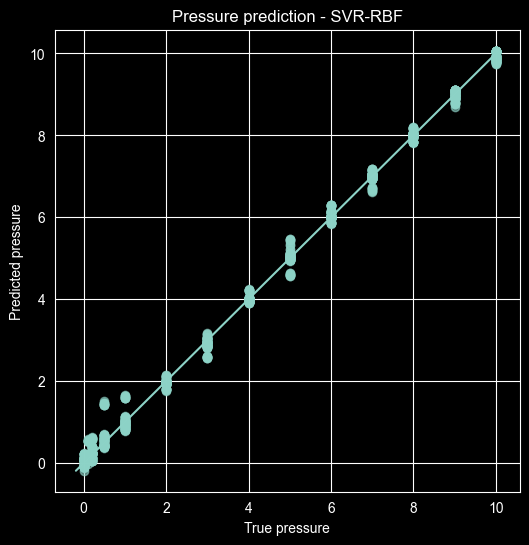

In [31]:
for model in pred_df["model"].unique():

    df_m = pred_df[
        pred_df["model"] == model
    ]

    plt.figure(figsize=(6, 6))

    plt.scatter(
        df_m["pressure_true"],
        df_m["pressure_pred"],
        alpha=0.6
    )

    min_v = min(df_m["pressure_true"].min(), df_m["pressure_pred"].min())
    max_v = max(df_m["pressure_true"].max(), df_m["pressure_pred"].max())

    plt.plot([min_v, max_v], [min_v, max_v])

    plt.xlabel("True pressure")
    plt.ylabel("Predicted pressure")
    plt.title(f"Pressure prediction - {model}")

    plt.grid(True)
    plt.show()

# 6. Predicted vs True — temperature

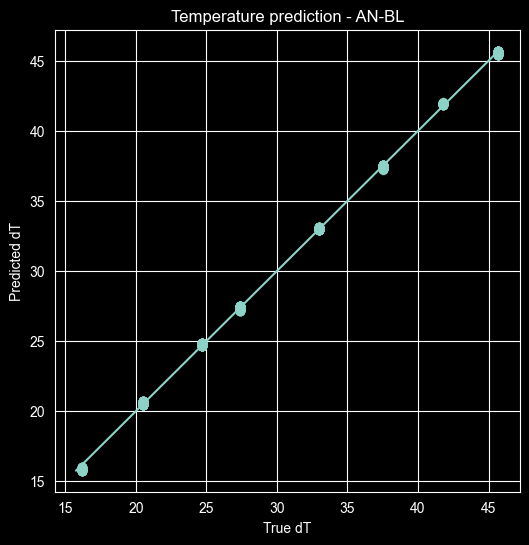

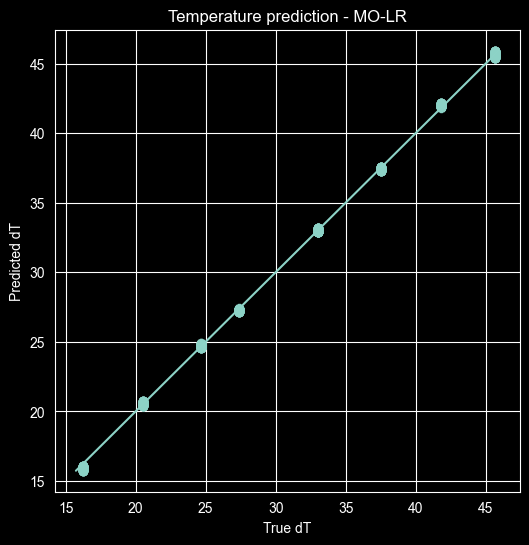

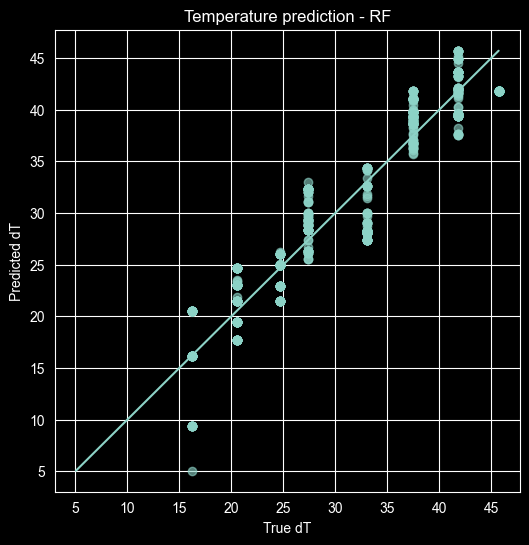

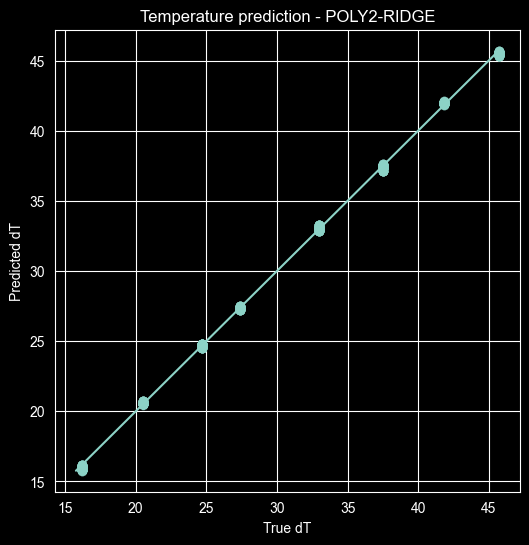

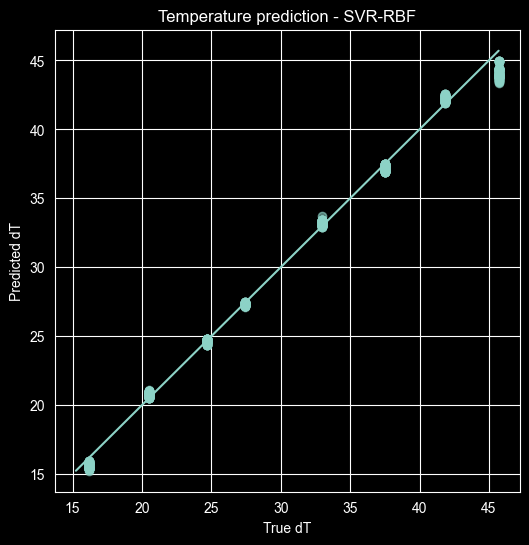

In [32]:
for model in pred_df["model"].unique():

    df_m = pred_df[
        pred_df["model"] == model
    ]

    plt.figure(figsize=(6, 6))

    plt.scatter(
        df_m["dT_true"],
        df_m["dT_pred"],
        alpha=0.6
    )

    min_v = min(df_m["dT_true"].min(), df_m["dT_pred"].min())
    max_v = max(df_m["dT_true"].max(), df_m["dT_pred"].max())

    plt.plot([min_v, max_v], [min_v, max_v])

    plt.xlabel("True dT")
    plt.ylabel("Predicted dT")
    plt.title(f"Temperature prediction - {model}")

    plt.grid(True)
    plt.show()

# 7. Fold analysis

In [33]:
fold_summary = (
    pred_df
    .groupby(["model", "fold"])
    [["pressure_abs_error", "dT_abs_error"]]
    .mean()
    .reset_index()
)

fold_summary.head()

,model,fold,pressure_abs_error,dT_abs_error
0,AN-BL,2,0.238672,0.346233
1,AN-BL,3,0.099962,0.091679
2,AN-BL,4,0.095791,0.064818
3,AN-BL,5,0.079743,0.077598
4,AN-BL,6,0.085034,0.052879


# 8. Heatmap błędów foldów

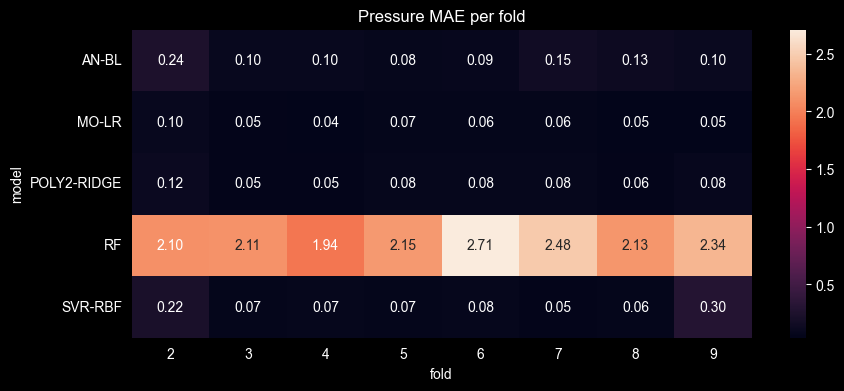

In [34]:
pivot_df = fold_summary.pivot(
    index="model",
    columns="fold",
    values="pressure_abs_error"
)

plt.figure(figsize=(10, 4))

sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".2f"
)

plt.title("Pressure MAE per fold")
plt.show()

# 9. Najgorsze próbki

In [37]:
# Zapis residuals
pred_df.to_csv(
    "Output_files/predictions_with_residuals.csv",
    index=False
)